# PCA from scratch

The goal is to implement PCA yourself using NumPy, apply it to a multivariate dataset, visualise what it does, reconstruct the data, and finally compare your implementation against scikit-learn.

## Project brief

Imagine you have a dataset containing several correlated measurements. Keeping every feature may be unnecessary because much of their variation may describe the same underlying pattern.

Your task is to build a small PCA pipeline that finds the directions containing the greatest variation and uses them to represent the dataset with fewer dimensions.

By the end, your pipeline should perform:

$X \rarr X_{centred} \rarr \Sigma \rarr\ (\lambda,v) \rarr sort \rarr\ select~components \rarr project \rarr\ reconstruct $

Don't use sklearn.decomposition.PCA until the final comparison.

## 1. Retrieval

1. What does centring a feature mean?

> To center a variables dataset around its mean, meaning to subtract the feature mean from each of the feature entries. The centered dataset will have a mean of zero

2. What information is contained on the diagonal of a covariance matrix?

> The indiviudal variances of the two variables being measured
 
3. What information is contained off the diagonal?

> the covariance of the two variables, or the measure to which both variables tend to vary together

4. What makes a vector an eigenvector of a matrix?

> If its direction is preserved after undergoing transformation by the matrix

5. For a covariance matrix, what does an eigenvalue tell us about its corresponding eigenvector?

> The eigenvalue measures the amount of variance in the dataset along the direction of the eigenvector

6. Why don't v and −v represent meaningfully different PCA directions?

> Because both v and -v lie along the same line going through the origin so therefore effectivley represent the same eigenvector direction

7. What does projecting a vector onto another direction do?

> It represents the component of one vector along the line spanned by another vector direction

8. If one eigenvalue is much larger than the others, what would you expect geometrically from the dataset?

> For the dataset to be tightly grouped along the line spanned by the eigenvector corresponding to this larger eigenvalue and very little variance in the direction perpendicular to this

## 2. Generate your dataset

In [184]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

n_samples = 150

latent = rng.normal(0, 1, n_samples)

feature_1 = 3.0 * latent + rng.normal(0, 0.5, n_samples)
feature_2 = 2.0 * latent + rng.normal(0, 0.7, n_samples)
feature_3 = -1.5 * latent + rng.normal(0, 0.6, n_samples)

X = np.column_stack([
    feature_1,
    feature_2,
    feature_3
])

Before doing anything else, investigate X.

Determine its shape and explicitly write down what the rows and columns represent.

Calculate the mean and standard deviation of each feature.

Then create three pairwise scatter plots:

- feature 1 against feature 2;
- feature 1 against feature 3;
- feature 2 against feature 3.

Write a short initial interpretation of the relationships you see.

In [185]:
print('X.shape:', X.shape)
# X.shape: (150, 3)
# Rows = observations, columns = variables (features)

X_means = X.mean(axis=0)
X_std_devs = X.std(axis=0)


X.shape: (150, 3)


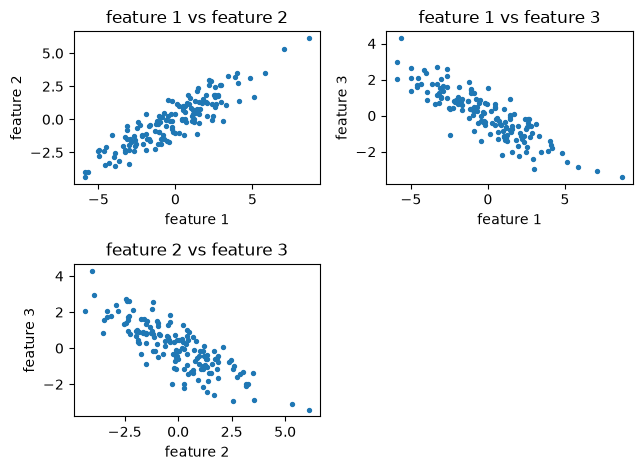

In [186]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(2, 2)

# plot 1:
ax[0, 0] = plt.subplot(2,2,1)
ax[0, 0].scatter(X[:,0], X[:,1], s=8)
ax[0, 0].set_title('feature 1 vs feature 2')
ax[0, 0].set_xlabel('feature 1')
ax[0, 0].set_ylabel('feature 2')

# plot 2:
ax[0, 1] = plt.subplot(2,2,2)
ax[0, 1].scatter(X[:,0], X[:,2], s=8)
ax[0, 1].set_title('feature 1 vs feature 3')
ax[0, 1].set_xlabel('feature 1')
ax[0, 1].set_ylabel('feature 3')

# plot 3:
ax[1, 0] = plt.subplot(2,2,3)
ax[1, 0].scatter(X[:,1], X[:,2], s=8)
ax[1, 0].set_title('feature 2 vs feature 3')
ax[1, 0].set_xlabel('feature 2')
ax[1, 0].set_ylabel('feature 3')

# remove blank 4th plot
ax[1,1].set_visible(False)

fig.tight_layout()
plt.show()


## Initial interpretation of datasets:

- features 1 and 2 tend to vary in the same direction, while feature 3 varies in the opposite direction to both of these features.
- features 2 and 3 appear to show the most variance in the direction perpendicular to the overall direction of the dataset.

## 3. Centre the dataset

Calculate the mean of each feature and construct:

`X_centered`

with the same shape as X.

Do this using NumPy broadcasting rather than a loop.

Verify that:

`X_centered.mean(axis=0)`

is approximately zero.

Your notebook should explain why PCA begins by centring the data.

A useful thought experiment: what would the eigenvectors describe if the entire dataset were translated far away from the origin but otherwise had exactly the same shape?

In [187]:
X_centered = X - X_means
print('X_centered shape:', X.shape)

print('X_centered mean is approximatley zero:', np.allclose(X_centered.mean(axis=0), 0))

X_centered shape: (150, 3)
X_centered mean is approximatley zero: True


> Without centring, the PCA calculation could become influenced by the dataset's displacement from the origin rather than purely by its internal variation. Centring places the mean at the origin so the covariance matrix describes how observations vary around their mean.

## 4. Calculate the covariance matrix

Calculate the covariance matrix yourself using matrix multiplication.

For an observation matrix containing centred data, you can generalise it to:

$$\Sigma = \frac{X^{T}X}{n-1} $$

In [188]:
cov_matrix = (X_centered.T @ X_centered)/(np.size(X_centered, 0) - 1)
print('Covariance matrix:\n', cov_matrix)
print('Shape:', cov_matrix.shape)
print('Calculated covariance matrix matches np.cov:', np.allclose(cov_matrix, np.cov(X, rowvar=False)))

Covariance matrix:
 [[ 6.99843333  4.36058901 -3.14343298]
 [ 4.36058901  3.38950631 -2.05895803]
 [-3.14343298 -2.05895803  1.8655999 ]]
Shape: (3, 3)
Calculated covariance matrix matches np.cov: True


- Variances lie on the diagonal:
  - $var(feat_1) = [0,0] = 7.00$
  - $var(feat_2) = [1,1] = 3.39$
  - $var(feat_3) = [2,2] = 1.87$

- Covariances:
  - $cov(feat_1, feat_2) = [1,0]~,~[0,1]$; positive covariance means datasets tend to vary in the same direction
  - $cov(feat_1, feat_3) = [2,0]~,~[0,2]$; negative covariance means datasets tend to vary in opposite directions
  - $cov(feat_2, feat_3) = [1,2]~,~[2,1]$; negative covariance means datasets tend to vary in opposite directions

## 5. Find the principal directions

In [189]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

for i in range(len(eigenvalues)):
  print(f'Σv{i+1} = λ{i+1}*v{i+1}: {np.allclose(cov_matrix @ eigenvectors[:,i],eigenvalues[i] * eigenvectors[:,i])}')

Σv1 = λ1*v1: True
Σv2 = λ2*v2: True
Σv3 = λ3*v3: True


## 6. Sort the components

`np.linalg.eigh()` does not return the components in the order PCA wants them.

PCA needs:

$$ \lambda_1 \geq \lambda_2 \geq \lambda_3$$


because the largest eigenvalue represents the direction containing the most variance.

Work out how to:

1. obtain indices that would sort the eigenvalues
2. reverse them into descending order
3. reorder both eigenvalues and the corresponding eigenvector columns



In [190]:
# Make a list of (eigenvalue, eigenvector) tuples
sorted_eig_pairs = [(eigenvalues[i], eigenvectors[:,i]) for i in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) tuples from high to low eigenvalues
sorted_eig_pairs.sort(key=lambda x: x[0], reverse=True)

for i in range(len(eigenvalues)):
  print(f'Σv{i+1} = λ{i+1}*v{i+1}: {np.allclose(cov_matrix @ sorted_eig_pairs[i][1],sorted_eig_pairs[i][0] * sorted_eig_pairs[i][1])}')

Σv1 = λ1*v1: True
Σv2 = λ2*v2: True
Σv3 = λ3*v3: True


## 7. Explained variance

Calculate the proportion of total variance represented by each principal component:

$$explained~variance~ratio_i = \frac{\lambda_i}{\sum \lambda_j}$$

Store the result in:

`explained_variance_ratio`

In [191]:
lambda_sum = np.sum(eigenvalues)
explained_variance_ratio = [sorted_eig_pairs[i][0] for i in range(len(sorted_eig_pairs))]/lambda_sum

print('explained_variance_ratio shape:', explained_variance_ratio.shape)
print('sum of explained_variance_ratio:', np.sum(explained_variance_ratio))

for i in range(len(sorted_eig_pairs)):
  print(f'Explained variance ratio {i+1} = {explained_variance_ratio[i] * 100: .2f}%')

explained_variance_ratio shape: (3,)
sum of explained_variance_ratio: 1.0
Explained variance ratio 1 =  92.99%
Explained variance ratio 2 =  3.96%
Explained variance ratio 3 =  3.05%


How many principal components would you retain if you wanted to preserve at least 90% of the variance?

Do not decide based on an arbitrary number of components. Base the decision on your calculated cumulative explained variance.

> Retain 1 principal component because PC1 alone explains more than 90% of the total variance

Create a plot showing cumulative explained variance for 1, 2 and 3 components.

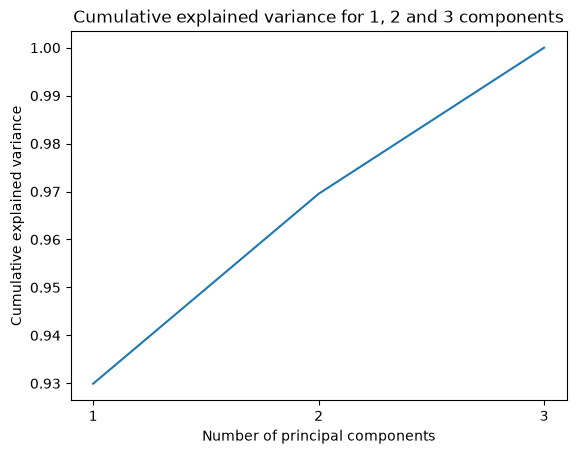

In [192]:
number_PCs = range(1, 4, 1)
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

fig, ax = plt.subplots()

ax.plot(number_PCs,cumulative_explained_variance)
plt.xticks(np.arange(1, 4, 1))
ax.set_title('Cumulative explained variance for 1, 2 and 3 components')
ax.set_xlabel('Number of principal components')
ax.set_ylabel('Cumulative explained variance')

plt.show()

## 8. Project into principal-component space

Now reduce your three-dimensional dataset to two dimensions.

Construct a matrix containing your first two principal directions:

`components`

Its required shape is:

`(3, 2)`

Then calculate:

$$Z=X_{centered}W$$

where $W$ contains those principal directions.

Your output:

`X_pca`

must have shape:

`(150, 2)`

Before running it, predict why that shape should result from the matrix multiplication.

> Because X_centered has shape (150, 3) and components has shape (3, 2) so the matrix multiplication product will have 150 rows and 2 columns

Then plot:

`PC1 against PC2`

This is now your original 3-feature dataset represented in two dimensions.

In [193]:
components = np.column_stack([sorted_eig_pairs[0][1], sorted_eig_pairs[1][1]])
print('components shape:', components.shape)

X_pca = X_centered @ components
print('X_pca shape:', X_pca.shape)

components shape: (3, 2)
X_pca shape: (150, 2)


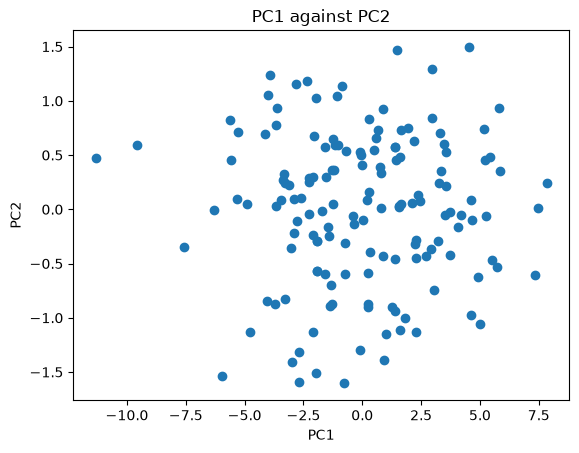

In [194]:
fig, ax = plt.subplots()

ax.scatter(X_pca[:,0], X_pca[:,1])
ax.set_title('PC1 against PC2')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

plt.show()

## 9. Investigate what PCA actually did

Calculate:

`np.cov(X_pca, rowvar=False)`

Look carefully at the result.

You should notice something important about the off-diagonal entries.

Explain why PCA has produced this property.

> In the new PCA coordinate system, the covariance matrix becomes diagonal:
$$W^{T}\Sigma W = \begin{bmatrix} \lambda_{1}&0 \cr 0&\lambda_{2} \end{bmatrix}$$
> The zeroes are why the PCs have zero covariance - this is by construction

Then compare the variances of PC1 and PC2 with your first two eigenvalues.

This is an important verification step: don't just report whether they match—explain why they should.

In [195]:
cov_matrix_pca = np.cov(X_pca, rowvar=False)
print('PC1 variance matches λ1:', np.allclose(cov_matrix_pca[0,0], sorted_eig_pairs[0][0]))
print('PC2 variance matches λ2:', np.allclose(cov_matrix_pca[1,1], sorted_eig_pairs[1][0]))

PC1 variance matches λ1: True
PC2 variance matches λ2: True


Each column of `X_pca` contains the coordinates of `X_centered` observations projected along one principal eigenvector. The variance of that column therefore measures how much the dataset varies along that eigenvector direction. Since the corresponding eigenvalue of the covariance matrix also represents the variance along that direction, **the variance of each principal component should equal its eigenvalue**. The eigenvalue and the variance of the corresponding X_pca column are two ways of measuring the same thing: the spread of the observations along that principal-component axis.

## 10. Reconstruct the data

Projection reduced:

  3 dimensions → 2 dimensions

Now map the observations back into the original three-feature space.

You know:

$$Z=X_{centered}W$$

Think about what operation involving W can take:

`(150, 2)`

back to:

`(150, 3)`

Call the reconstructed data:

`X_reconstructed`

Remember that your PCA representation came from centred data.

Therefore, think carefully about what else must be restored before comparing the reconstructed points with the original X.

> $$Z=X_{centered}W$$
> Because the columns of W are othogonal eigenvectors, $$X_{reconstructed,~centered}=ZW^{T},$$
> $$ZW^{T}=X_{centered}WW^{T},$$
> Since $WW^{T} \ne I$ due to missing information existing along PC3;
> $$ZW^{T} \approx X_{centered}$$
> Therefore:
> $$X_{reconstructed} = ZW^{T} + mean$$

In [196]:
X_reconstructed = X_pca @ components.T + X_means

Calculate the mean squared reconstruction error:

$$MSE=\frac{1}{N}\sum (original-reconstructed)^{2}$$

You may implement that directly with NumPy.

In [197]:
MSE = np.mean((X - X_reconstructed) ** 2)

Explain:

Why isn't the reconstruction perfect?

> Because when the centered data is projected along 2 out of 3 of the principal components, so the information that existed only laong PC3 is lost during this projection. Therefore when we reconstruct the dataset from the X_pca dataset the reconstruction is not perfect due to this missing information. Effectivley we are projecting a three dimensional dataset across only two dimensions then attempting to reconstruct this 3-dimensional dataset from the 2-d data, so information will always get lost in this process.

## 11. Compare 1, 2 and 3 components

Repeat the projection/reconstruction using:

- 1 component
- 2 components
- 3 components

For each one, record:

- dimensionality;
- cumulative explained variance;
- reconstruction MSE.

Present the results clearly.

Then explain the trade-off:

$$compression \leftrightarrow information~retained$$

With all three components, think carefully about what the reconstruction error should theoretically approach.

In [198]:
# Full component matrix
W = np.column_stack([sorted_eig_pairs[0][1], sorted_eig_pairs[1][1], sorted_eig_pairs[2][1]])

# 1 component
X_pca_1 = X_centered @ W[:,:1]
X_reconstructed_1 = X_pca_1 @ W[:,:1].T + X_means
mse_1 = np.mean((X - X_reconstructed_1) ** 2)


# 2 components (repeat)
X_pca_2 = X_centered @ W[:,:2]
X_reconstructed_2 = X_pca_2 @ W[:,:2].T + X_means
mse_2 = np.mean((X - X_reconstructed_2) ** 2)

# 3 components
X_pca_3 = X_centered @ W[:,:3]
X_reconstructed_3 = X_pca_3 @ W[:,:3].T + X_means
mse_3 = np.mean((X - X_reconstructed_3) ** 2)

# Combine results for part 12 verification
X_reconstructed_results = [X_reconstructed_1, X_reconstructed_2, X_reconstructed_3]

number_PC = [1, 2, 3]
MSEs = [mse_1, mse_2, mse_3]

for i in range(3):
  print(f'for {number_PC[i]}-D PCA, cumulative explained variance = {cumulative_explained_variance[i]: .2f}, reconstruction MSE = {MSEs[i]: .2f}')


for 1-D PCA, cumulative explained variance =  0.93, reconstruction MSE =  0.28
for 2-D PCA, cumulative explained variance =  0.97, reconstruction MSE =  0.12
for 3-D PCA, cumulative explained variance =  1.00, reconstruction MSE =  0.00


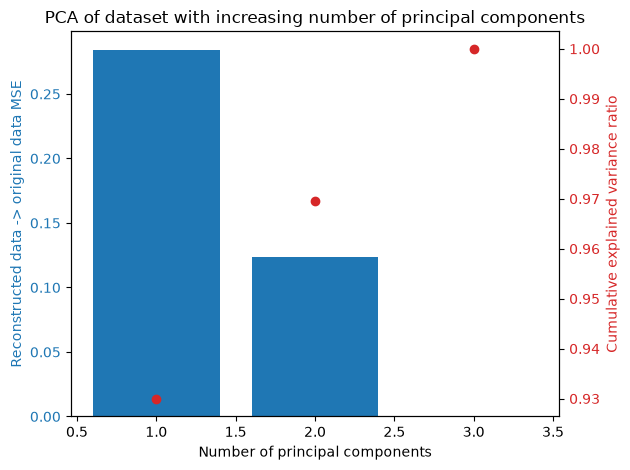

In [199]:
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Number of principal components')
ax1.set_ylabel('Reconstructed data -> original data MSE', color=color)
ax1.bar(number_PC, MSEs, label='', color=color)
ax1.tick_params(axis ='y', labelcolor = color) 

ax2 = ax1.twinx() 

color = 'tab:red'
ax2.set_ylabel('Cumulative explained variance ratio', color = color) 
ax2.scatter(number_PC, cumulative_explained_variance, color = color) 
ax2.tick_params(axis ='y', labelcolor = color) 

ax1.set_title('PCA of dataset with increasing number of principal components')

fig.tight_layout()
plt.show()

Using fewer principal components gives a lower-dimensional representation but discards some variance. If most variance is concentrated in the first few components, substantial dimensionality reduction can produce little reconstruction error. Retaining more components preserves more variance but reduces the amount of compression.

## 12 — Turn it into reusable Python

Up to this point, notebook calculations are fine. Now refactor the important operations into functions.

In [200]:
def fit_pca(X):
  """
  Centers dataset columns, calculates the covariance matrix and principal component directions

  Args:
    X (np.array((N, number_variables))): dataset where rows: observations, columns: variables
  
  Returns:
    mean (int[number_of_variables]): array of means of X columns
    eigenvalues (int[number_of_variables]): array of covariance matrix eigenvalues sorted in decreasing order
    components (np.array((number_variables, number_variables))): [number_variables X number_variables] matrix containing sorted principal components
    explained_variance_ratio (int[number_of_variables]): proportion of total variance represented by each principal component
  """

  # Confirm dataset contains at least two variables
  try: X[0,1]
  except IndexError:
    raise(IndexError('Error: Dataset must contain more than one variable column'))

  n_variables = np.size(X[0,:])

  # Calculate feature means
  mean = X.mean(axis=0)

  # Center dataset
  X_centered = X - mean

  # Calculate covariance matrix
  cov_matrix = np.cov(X_centered, rowvar=False)

  # Calculate eigenvalues/eigenvectors
  eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

  # Sort the eigenvalue and eigenvector pairs according to descending eigenvalues
  sort_indices = np.argsort(eigenvalues)[::-1]

  sorted_eigenvalues = eigenvalues[sort_indices]
  components = eigenvectors[:, sort_indices]

  # Calculate explained variance ratios
  explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)

  return mean, sorted_eigenvalues, components, explained_variance_ratio
  

In [201]:
def transform_pca(X, mean, components, pc_dimensions):
  """
  Transforms observations into principal component space

  Args:
    X (np.array((N, number_variables))): dataset where rows: observations, columns: variables
    mean (int[]): array of means of X columns
    components (np.array((number_variables, number_variables))): [number_variables X number_variables] matrix containing sorted covariance eigenvectors
    pc_dimensions (int): number of principle components to consider during transform

  Returns:
    X_pca (np.array((N, pc_dimensions))): transformed dataset in PC coordinates
  """
  try:components[pc_dimensions-1,0]
  except IndexError:
    raise(IndexError('Error: Dimensionality must not exceed the number of variables'))

  # Center dataset
  X_centered = X - mean 

  # Project observations onto selected components
  X_pca = X_centered @ components[:,:pc_dimensions]

  return X_pca



In [202]:
def inverse_transform_pca(X_pca, mean, components, pc_dimensions):
  """
  Reconstruct original feature space from X_pca

  Args:
    X_pca (np.array((N, pc_dimensions))): transformed dataset in PC coordinates
    mean (int[]): array of means of X columns
    components (np.array((number_variables, number_variables))): [number_variables X number_variables] matrix containing sorted covariance eigenvectors
    pc_dimensions (int): number of principle components to consider during transform

  Returns:
    X_reconstructed (np.array((N, number_variables))): reconstructed dataset in feature coordinates
  """

  X_reconstructed = X_pca @ components[:,:pc_dimensions].T + mean
  
  return X_reconstructed

In [203]:
# 1. LEARN
try: mean, eigenvalues, components, explained_variance_ratio = fit_pca(X)
except IndexError as error:
  print(error)

# 2. DECIDE
pc_dimensions = 2

# 3. COMPRESS / TRANSFORM
try:
  X_pca = transform_pca(X, mean, components, pc_dimensions)
except IndexError as error:
  print(error)

# 4. RECONSTRUCT
X_reconstructed_new = inverse_transform_pca(X_pca, mean, components, pc_dimensions)

# 5. VERIFY
print(
  'PCA functions reproduce reconstructed dataset:',
  np.allclose(X_reconstructed_results[pc_dimensions - 1], X_reconstructed_new)
)


PCA functions reproduce reconstructed dataset: True


## 13. Compare with scikit-learn

Only now use the library implementation.

You may need:

In [204]:
from sklearn.decomposition import PCA

Fit a two-component PCA model.

Compare your implementation against scikit-learn for:

- explained variance
- explained variance ratio
- projected data
- reconstructed data

In [205]:
pca = PCA(n_components=2)

# Scikit-learns PCA.fit() automatically centers the data
pca.fit(X)

# Explained variance and variance ratios
explained_variance_sklearn = pca.explained_variance_
explained_variance_ratio_sklearn = pca.explained_variance_ratio_

# Project onto the principal compoonents
X_pca_sklearn = pca.transform(X)

# Reconstruction
X_reconstructed_sklearn = pca.inverse_transform(X_pca_sklearn)

# Verification:
print('Explained variances match:', np.allclose(explained_variance_sklearn, [sorted_eig_pairs[0][0], sorted_eig_pairs[1][0]]))
print('Explained variance ratios match:', np.allclose(explained_variance_ratio_sklearn, explained_variance_ratio[:2]))
print('Projected datasets match:', 
      np.allclose(X_pca_sklearn, X_pca_2) or 
      np.allclose(X_pca_sklearn @ np.array([[-1, 0],[0, 1]]), X_pca_2) or
      np.allclose(X_pca_sklearn @ np.array([[1, 0],[0, -1]]), X_pca_2) or
      np.allclose(X_pca_sklearn @ np.array([[-1, 0],[0, -1]]), X_pca_2)
      )
print('Reconstructed datasets match:', np.allclose(X_reconstructed_sklearn, X_reconstructed_2))

Explained variances match: True
Explained variance ratios match: True
Projected datasets match: True
Reconstructed datasets match: True


When checking whether the projected datasets match I check against PC datasets multiplied by differed 2x2 matrices to account for PCA eigenvectors having opposite signs while still representing the same principal axis. These check:
- opposite sign in the PC1 direction: $\begin{bmatrix} \ -1&0 \cr 0&1 \end{bmatrix}$

- opposite sign in the PC2 direction: $\begin{bmatrix} \ 1&0 \cr 0&-1 \end{bmatrix}$

- opposite sign in both PC directions: $\begin{bmatrix} \ -1&0 \cr 0&-1 \end{bmatrix}$

## 14. Final report

1. What problem does PCA solve?

> By projecting data onto new axes, PCA simplifies high-dimensional datasets while retaining as much variance as possible

2. Why must the dataset be centred?

> Without centring, the PCA calculation could become influenced by the dataset's displacement from the origin rather than purely by its internal variation. Centring places the mean at the origin so the covariance matrix describes how observations vary around their mean.

3. Why do we eigendecompose the covariance matrix?

> The eigenvectors of the covariance matrix represent the principal components of the dataset and are used to transform the dataset from feature space to PC space

4. What does the eigenvector associated with the largest eigenvalue represent?

> The eigenvector associated with the largest eigenvalue represents the direction along which the centred dataset has the greatest variance. Its corresponding eigenvalue quantifies the amount of variance along this direction.

5. What does explained variance ratio mean?

> How much of the total variance is captured by each PC

6. What happens mathematically when you discard a principal component?

> Discarding a principal component removes each observation's coordinate along that eigenvector direction. Reconstruction then projects the data onto the subspace spacnned by the retained eigenvectors, so the variance associated with the discarded components is lost.

7. Why are principal components uncorrelated in the transformed dataset?

> In the principal-component basis, the covariance matrix becomes diagonal:
> $$W^{T}\Sigma W = \Lambda$$
> The diagonal entries are the eigenvalues, representing the variance of each principal component, while the off-diagonal entries are zero. Therefore the principal components have zero pairwise covariances and are uncorrelated. 

8. What information is lost when reducing three dimensions to two?

> The component of each observation along the discarded PC3 direction is lost. Equivalently, the reconstructed observations lose the variance associated with $\lambda_{3}$

9. When might PCA be a poor preprocessing choice?

> If the data has complex, non-linear relationships

9. Which part of your implementation was hardest to reason about?

> conceptualising going from the covariance matrix to PCA space and how the eigenvectors related to PCA space (and why by design the covariance of the PCs is zero)

## Project limitations

- PCA based on the covariance matrix is sensitive to feature scale. A feature measured on a much larger numerical scale can dominate the principal components even if it is not intrinsically more important. Standardising features to zero mean and unit variance can address this when differences in units or scale should not determine their importance
- This project assumes linear relationships between the features - this is fine if we know this to be the case (we initially inspected plots of the raw data so this is true) however we shouldn't assume that PCA can blindly be applied.
- This notebook doesn't do the best job of displaying results - perhaps outputting to a csv, or displaying results in a table would be a better way of showing the results of PCA.